In [1]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)
csv_path = os.path.join(path, "diabetes_binary_health_indicators_BRFSS2015.csv")
df = pd.read_csv(csv_path)
os.makedirs("images", exist_ok=True)

RANDOM_STATE = 67

## Análise Exploratória

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

In [5]:
duplicates = df[df.duplicated()]
print("Duplicate Rows : ",len(duplicates))
duplicates.head()

Duplicate Rows :  24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0


In [6]:
df.drop_duplicates(inplace = True)

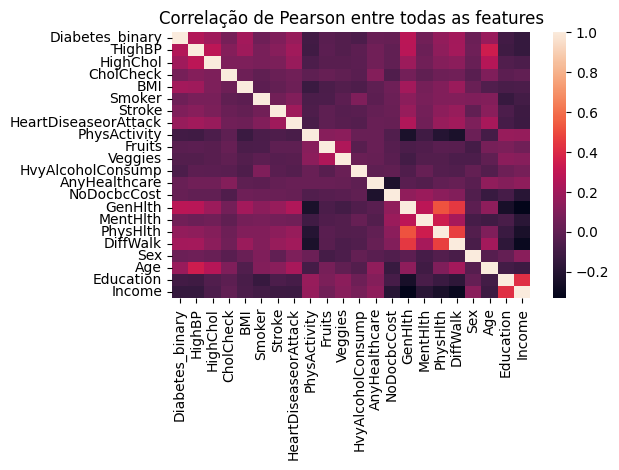

In [7]:
corr_completa = df.corr(method='pearson')
sns.heatmap(
    corr_completa
)
plt.title('Correlação de Pearson entre todas as features')
plt.savefig("images\\full_pearson.png")
plt.tight_layout()
plt.show()


In [8]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Pré Processamento

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
X_completo = df.drop(columns=['Diabetes_binary'])
y_completo = df['Diabetes_binary']

#Usando sampling: pega só 0.20 do dataset original.
#train_size=0.20
X, _, y, _ = train_test_split(
    X_completo, y_completo, 
    train_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y_completo
)

#test_size =0.20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Selecao Features

In [12]:
from sklearn.feature_selection import mutual_info_classif

In [13]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)

# Criar um DataFrame para facilitar a visualização e ordenação (Ranking)
mi_features = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# Apresentar a quantidade inicial de atributos e o ranking gerado
print(f"Quantidade inicial de atributos: {X.shape[1]}")
print("\nRanking de Importância das Features:")
mi_features

Quantidade inicial de atributos: 21

Ranking de Importância das Features:


,Feature,MI_Score
0,GenHlth,0.042471
1,HighBP,0.037582
2,BMI,0.026601
3,HighChol,0.022075
4,DiffWalk,0.020220
5,PhysHlth,0.015841
6,Age,0.015669
7,HeartDiseaseorAttack,0.012089
8,Education,0.010089
9,Income,0.008394


C:\Users\Miguel\AppData\Local\Temp\ipykernel_10956\3057217112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')


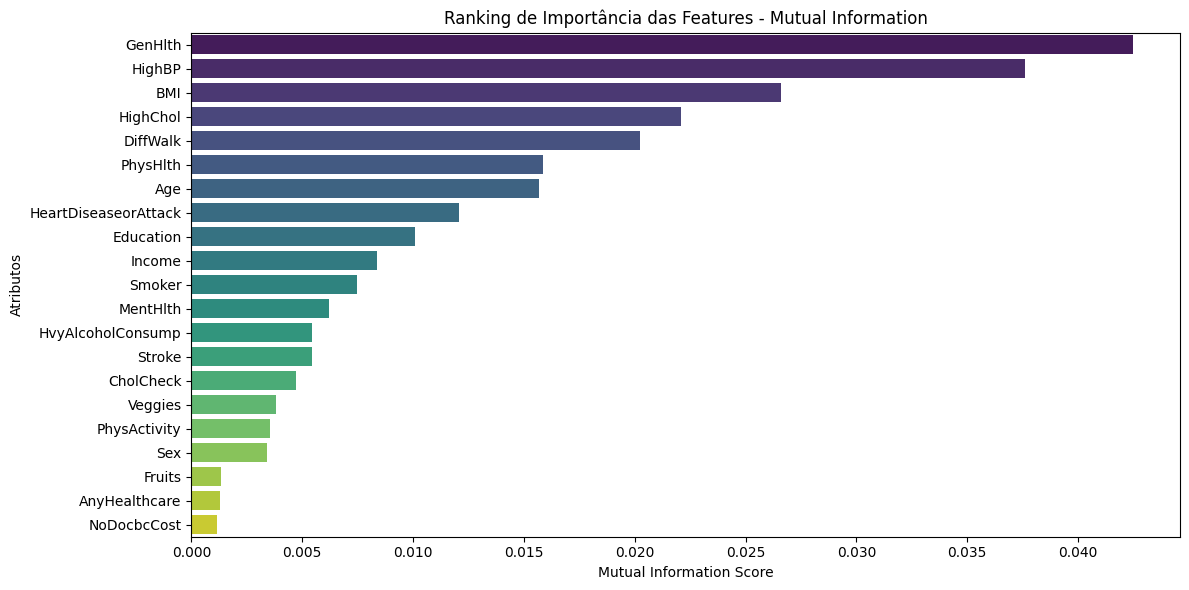

Quantidade final de atributos selecionados: 10
Features escolhidas: ['GenHlth', 'HighBP', 'BMI', 'HighChol', 'DiffWalk', 'PhysHlth', 'Age', 'HeartDiseaseorAttack', 'Education', 'Income']


In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')
plt.title('Ranking de Importância das Features - Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

# Critério de corte: Selecionar as Top 10 features com maior score de MI
K_FEATURES = 10
selected_features = mi_features['Feature'].head(K_FEATURES).tolist()

print(f"Quantidade final de atributos selecionados: {K_FEATURES}")
print(f"Features escolhidas: {selected_features}")

# Criar conjuntos de dados filtrados apenas com as features selecionadas
X_train_selected = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features]
X_test_selected = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features]

Uso de Mutual Information pois avalia a dependência estatística não-linear entre os sintomas médicos e o diabetes através de conceitos de entropia
ref complementar: https://www.ibm.com/think/topics/feature-selection

## Classificação Binária
### Markdown

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [16]:
mlp_all = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 2 camadas ocultas (justificar no relatório)
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,                  # Controla as épocas
    random_state=RANDOM_STATE,
    early_stopping=False          # Desativado por enquanto (exigido na Etapa 7)
)
mlp_all.fit(X_train_scaled, y_train)

C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=128, hidden_layer_sizes=(64, 32), max_iter=150,
              random_state=67)

In [17]:
mlp_sel = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False
)
mlp_sel.fit(X_train_selected, y_train)

C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=128, hidden_layer_sizes=(64, 32), max_iter=150,
              random_state=67)

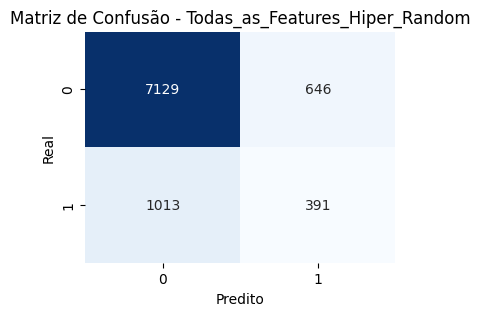

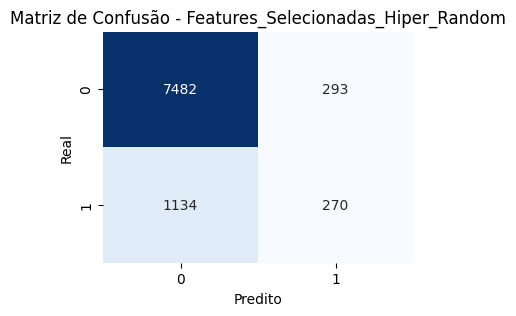


Comparativo de Desempenho (Etapa 3 e 4):


,Cenário,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Todas_as_Features_Hiper_Random,0.819261,0.377049,0.278490,0.320361,0.750299
1,Features_Selecionadas_Hiper_Random,0.844536,0.479574,0.192308,0.274530,0.775117


In [18]:
def avaliar_classificacao_binaria(modelo, X_test_data, y_true, nome_cenario):
    preds = modelo.predict(X_test_data)
    probs = modelo.predict_proba(X_test_data)[:, 1]
    
    metrics = {
        "Cenário": nome_cenario,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds),
        "F1-Score": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    }
    
    # Exibir a Matriz de Confusão exigida
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome_cenario}')
    plt.ylabel('Real')
    plt.xlabel('Predito')

    plt.savefig(f"images\\{nome_cenario}.png")
    plt.show()
    
    return metrics

# Avaliar ambos os modelos
res_all = avaliar_classificacao_binaria(mlp_all, X_test_scaled, y_test, "Todas_as_Features_Hiper_Random")
res_sel = avaliar_classificacao_binaria(mlp_sel, X_test_selected, y_test, "Features_Selecionadas_Hiper_Random")

# Tabela comparativa final para discussão no relatório
df_comparativo = pd.DataFrame([res_all, res_sel])
print("\nComparativo de Desempenho (Etapa 3 e 4):")
df_comparativo

Apesar de accuracy alta, Recall foi muito baixo. Acredito que mudando os hiper parametros conseguimos melhorar essa parte (etape 6)

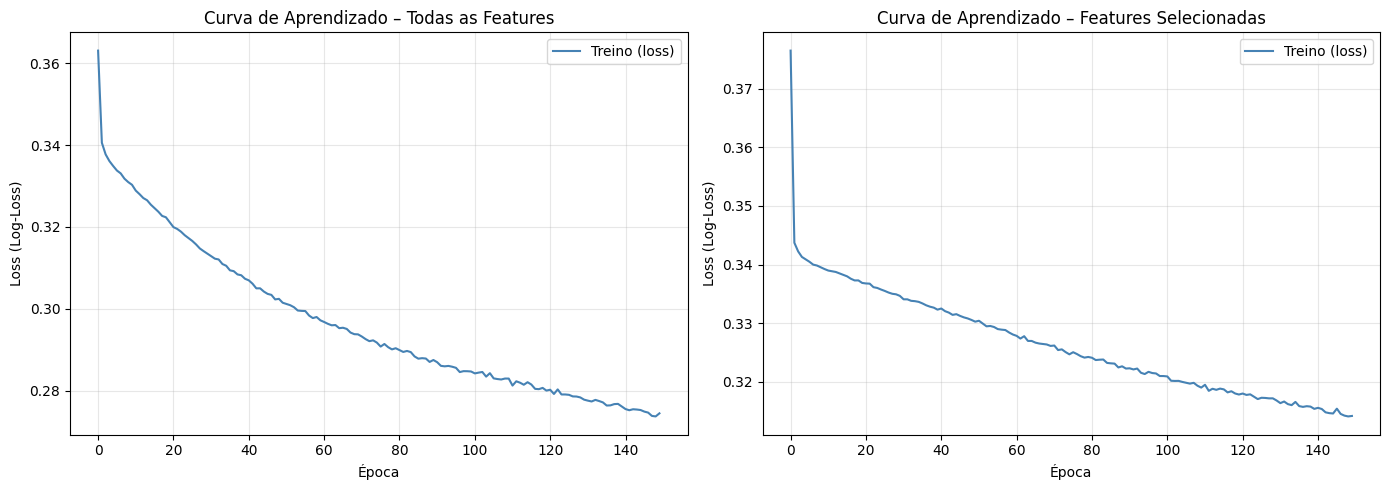

In [19]:
# Curva de aprendizado (loss por época) - Etapa 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, titulo in zip(
    axes,
    [mlp_all, mlp_sel],
    ["Todas as Features", "Features Selecionadas"]
):
    ax.plot(modelo.loss_curve_, label="Treino (loss)", color="steelblue")
    ax.set_title(f"Curva de Aprendizado – {titulo}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss (Log-Loss)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images\\curva_aprendizado_binaria.png")
plt.show()

## Problema de regressão com MLP

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [21]:
X_reg = df.drop(columns=['BMI', 'Diabetes_binary'])
y_reg = df['BMI']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

In [22]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [23]:
features_reg = [f for f in selected_features if f != 'BMI']
X_train_r_sel = pd.DataFrame(X_train_r_scaled, columns=X_reg.columns)[features_reg]
X_test_r_sel = pd.DataFrame(X_test_r_scaled, columns=X_reg.columns)[features_reg]

In [24]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False # USAR QUANDO CHEGAR NA ETAPA 7
)
mlp_reg.fit(X_train_r_sel, y_train_r)
preds_r = mlp_reg.predict(X_test_r_sel)

C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
mse = mean_squared_error(y_test_r, preds_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, preds_r)
r2 = r2_score(y_test_r, preds_r)

print("\nMétricas de Desempenho da Regressão:")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")
print(f"R² Score (Coeficiente de Determinação): {r2:.4f}")


Métricas de Desempenho da Regressão:
MAE (Erro Médio Absoluto): 4.4740
MSE (Erro Quadrático Médio): 40.6494
RMSE (Raiz do Erro Quadrático Médio): 6.3757
R² Score (Coeficiente de Determinação): 0.1236


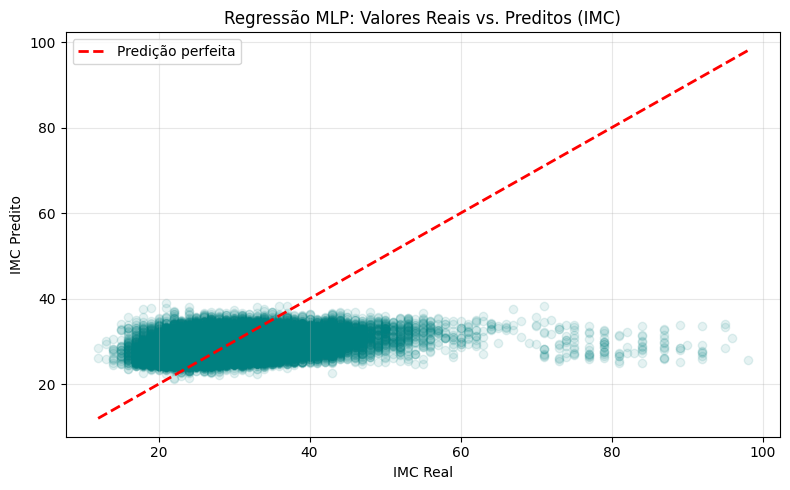

In [26]:
# 1. Valores reais vs. preditos
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, preds_r, alpha=0.1, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Predição perfeita')
plt.title('Regressão MLP: Valores Reais vs. Preditos (IMC)')
plt.xlabel('IMC Real')
plt.ylabel('IMC Predito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\regressao_real_vs_pred.png")
plt.show()

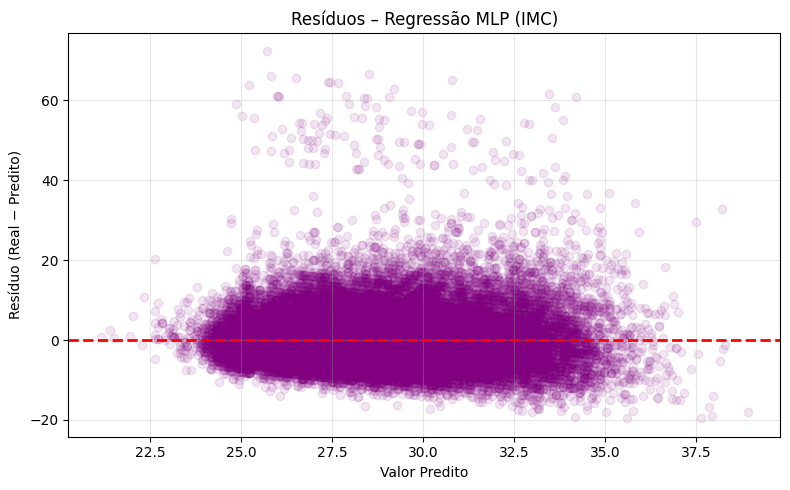

In [27]:
residuos = y_test_r.values - preds_r

plt.figure(figsize=(8, 5))
plt.scatter(preds_r, residuos, alpha=0.1, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Resíduos – Regressão MLP (IMC)')
plt.xlabel('Valor Predito')
plt.ylabel('Resíduo (Real − Predito)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\regressao_residuos.png")
plt.show()

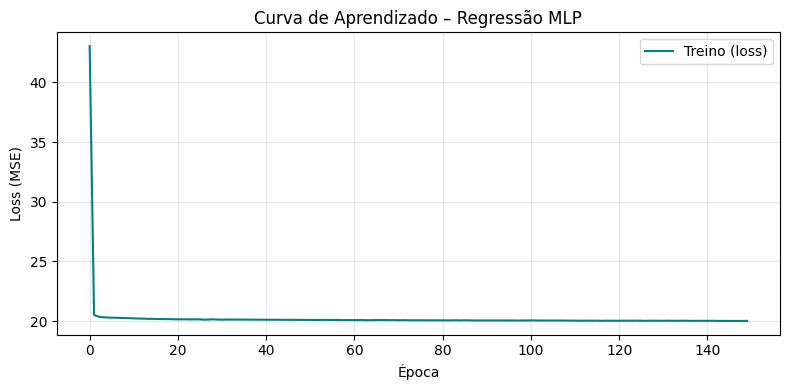

In [28]:
# 3. Curva de aprendizado da regressão
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_, color='teal', label='Treino (loss)')
plt.title('Curva de Aprendizado – Regressão MLP')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\curva_aprendizado_regressao.png")
plt.show()

## Otimização de hiperparâmetros
TODOS OS RESULTADOS ATÉ AQUI FORAM HORRIVEIS!
Tentar usar o Optuna (etape 6) para tentar melhorar

In [29]:
import optuna
import logging

In [30]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [31]:
def objective(trial):
    n_layer1 = trial.suggest_int('n_layer1', 32, 128, step=32)
    n_layer2 = trial.suggest_int('n_layer2', 16, 64, step=16)
    
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    model = MLPClassifier(
        hidden_layer_sizes=(n_layer1, n_layer2),
        activation=activation,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        solver='adam',
        max_iter=150,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_selected, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    
    score = f1_score(y_val, preds, zero_division=0)
    return score

In [32]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Miguel\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warning

In [33]:
print(f"Melhor F1-Score alcançado na validação: {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

Melhor F1-Score alcançado na validação: 0.3190
Melhores Hiperparâmetros encontrados:
  - n_layer1: 32
  - n_layer2: 48
  - activation: relu
  - learning_rate_init: 0.00134803459133371
  - batch_size: 128


## Regularização

In [34]:
best_params = study.best_params

In [37]:
mlp_regularized = MLPClassifier(
    hidden_layer_sizes=(best_params['n_layer1'], best_params['n_layer2']),
    activation=best_params['activation'],
    learning_rate_init=best_params['learning_rate_init'],
    batch_size=best_params['batch_size'],
    solver='adam',
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10
)
mlp_regularized.fit(X_train_selected, y_train)

MLPClassifier(batch_size=128, early_stopping=True, hidden_layer_sizes=(32, 48),
              learning_rate_init=0.00134803459133371, max_iter=150,
              random_state=67, validation_fraction=0.15)

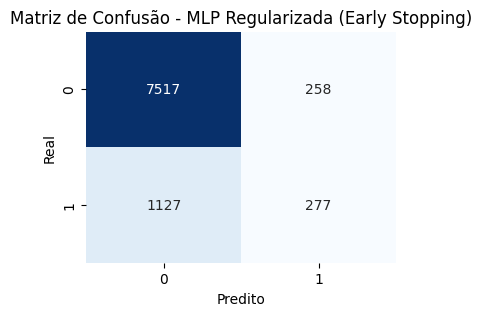

In [38]:
res_reg = avaliar_classificacao_binaria(mlp_regularized, X_test_selected, y_test, "MLP Regularizada (Early Stopping)")


In [39]:
df_comparativo_final = pd.DataFrame([res_all, res_sel, res_opt, res_reg])
df_comparativo_final

,Cenário,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Todas_as_Features_Hiper_Random,0.819261,0.377049,0.278490,0.320361,0.750299
1,Features_Selecionadas_Hiper_Random,0.844536,0.479574,0.192308,0.274530,0.775117
2,MLP Otimizada (Optuna),0.843229,0.470289,0.197293,0.277973,0.778989
3,MLP Regularizada (Early Stopping),0.849112,0.517757,0.197293,0.285714,0.798942


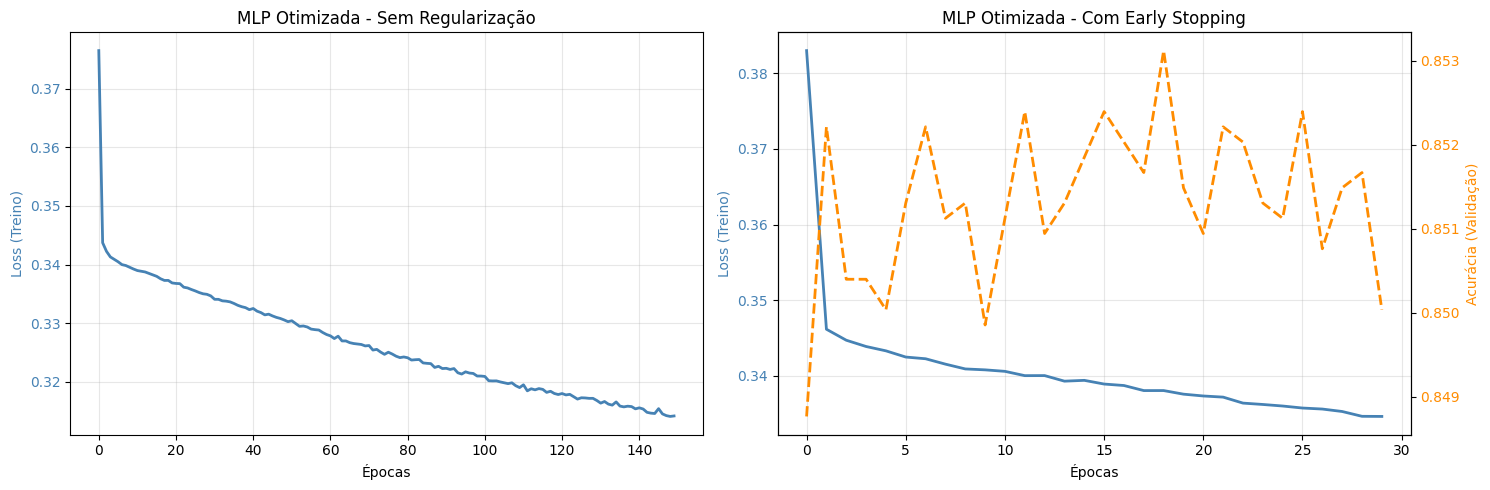

In [43]:
# =====================================================================
# ETAPA 7 – CORREÇÃO DO GRÁFICO DE APRENDIZADO (TREINO VS VALIDAÇÃO)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico do Modelo Sem Regularização
axes[0].plot(mlp_sel.loss_curve_, label="Loss de Treino", color="steelblue", lw=2)
axes[0].set_title("MLP Otimizada - Sem Regularização")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss (Treino)", color="steelblue")
axes[0].tick_params(axis='y', labelcolor='steelblue')
axes[0].grid(True, alpha=0.3)

# 2. Gráfico do Modelo Com Early Stopping (Dois Eixos Y)
axes[1].plot(mlp_regularized.loss_curve_, label="Loss de Treino", color="steelblue", lw=2)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss (Treino)", color="steelblue")
axes[1].tick_params(axis='y', labelcolor='steelblue')

# Criar o segundo eixo para a Acurácia de Validação
ax_val = axes[1].twinx()
ax_val.plot(mlp_regularized.validation_scores_, label="Acurácia de Validação", color="darkorange", linestyle='--', lw=2)
ax_val.set_ylabel("Acurácia (Validação)", color="darkorange")
ax_val.tick_params(axis='y', labelcolor='darkorange')

axes[1].set_title("MLP Otimizada - Com Early Stopping")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("images/overfitting_analise.png")
plt.show()